In [1]:
!hostname
# !pip install scikit-image

bell-a000.rcac.purdue.edu


## Debug for pairing the blocking and seeding events in SH
1. read in the SH blocking and seeding label/date data
2. pair the events
3. get basic statistics: seeding number/seeding climatology/seeding developed percentage
4. read in the BAM data and track data
5. calculate the probability of seeding develop into blocking under high BAM/low BAM state

In [2]:
###### This code is to track all blocking events ######
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import datetime as dt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd
import cv2
import copy
import matplotlib.path as mpath
import pickle
import glob
from netCDF4 import Dataset
from skimage import feature, segmentation, measure
import sys
from collections import defaultdict

### A function to calculate distance between two grid points on earth ###
from math import radians, cos, sin, asin, sqrt
 
# 00 function --------------------------------

regions = ["ATL", "NP", "SP"]
seasons = [ "ALL", "DJF", "JJA"]
seasonsmonths = [[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], [12, 1, 2], [6, 7, 8]]
blkTypes = ["Ridge", "Trough", "Dipole"]
cycTypes = ["AC", "CC"]

def Region_ERA(regionname): 
    if regionname == "ATL": 
        lat_min, lat_max, lon_min, lon_max = 45, 75, 300, 60
    elif regionname == "NP": 
        lat_min, lat_max, lon_min, lon_max = 40, 70, 130, 250
    elif regionname == "SP": 
        lat_min, lat_max, lon_min, lon_max = -75, -45, 180, 300
    return lat_min, lat_max, lon_min, lon_max

def haversine(lon1, lat1, lon2, lat2): # 
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # transform decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
 
    # haversine equation
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # earth radius
    return c * r * 1000

def findClosest(lati, latids):

    if isinstance(lati, np.ndarray):  # if lat is an array
        closest_indices = []
        for l in lati:  
            diff = np.abs(l - latids)
            closest_idx = np.argmin(diff) 
            closest_indices.append(closest_idx)
        return closest_indices
    else:
        # if lat is a single value
        diff = np.abs(lati - latids)
        return np.argmin(diff) 


In [ ]:
datasets = ["ERA5", "MERRA2", "JRA3Q"]

OUT_DIR_List = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q"
}
yearnameList = {
    "ERA5": "1979_2025",
    "MERRA2": "1980_2025",
    "JRA3Q": "1979_2025"
}
timerefFile = {
    "ERA5": "/scratch/bell/hu1029/Data/processed/ERA5_Z500_6hr_1979_2025_1dg.nc",
    "MERRA2": "/scratch/bell/hu1029/Data/processed/MERRA2_Z500_6hr_1980_2025_1dg.nc",
    "JRA3Q": "/scratch/bell/hu1029/Data/processed/JRA3Q_Z500_6hr_1979_2025_1dg.nc"
}
latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lat_1979_2025_6hr.npy"
}
lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lon_1979_2025_6hr.npy"
}
TRACK_latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lat_1979_2025_6hr.npy"
}
TRACK_lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lon_1979_2025_6hr.npy"
}

In [4]:
import numpy as np
import matplotlib.pyplot as plt

blktype = 1
trackType = 'AC'

lonarr = np.arange(-30, 30)
lagarr = np.arange(0, 10)

levels_fill = np.arange(0.05, 0.25, 0.01)
levels_cont = np.arange(0, 1.8, 0.1)

cmap = plt.get_cmap('Reds').copy()
cmap.set_under('white')

datasets = ["ERA5", "MERRA2", "JRA3Q"]
hemis = ['NH', 'SH']
situations = ['Developed', 'Decayed']

# store averaged fields
mean_lwa = {}
mean_track = {}
mean_count = {}

for kk in hemis:
    for situation in situations:
        lwa_list = []
        track_list = []
        count_list = []

        for dtname in datasets:
            OUTDIR = OUT_DIR_List[dtname]

            centeredComp_latavg = np.load(
                f'{OUTDIR}/{dtname}_{kk}_{blktype}_centeredComp_latavg_{situation}.npy'
            )

            centeredCompTrack_latavg = np.load(
                f'{OUTDIR}/{dtname}_{kk}_{blktype}_{trackType}_centeredCompTrack_latavg_{situation}.npy'
            )
            # read in event count for this dataset and situation
            with open(f'{OUTDIR}/{dtname}_{kk}_{blktype}_{situation}_targetindices.pkl', 'rb') as f:
                targetindices = pickle.load(f)

            lwa_list.append(centeredComp_latavg)
            track_list.append(centeredCompTrack_latavg)
            count_list.append(len(targetindices))

        mean_lwa[(kk, situation)] = np.nanmean(np.stack(lwa_list, axis=0), axis=0)
        mean_track[(kk, situation)] = np.nanmean(np.stack(track_list, axis=0), axis=0)
        mean_count[(kk, situation)] = np.nanmean(count_list)


/tmp/ipykernel_795973/3615416574.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


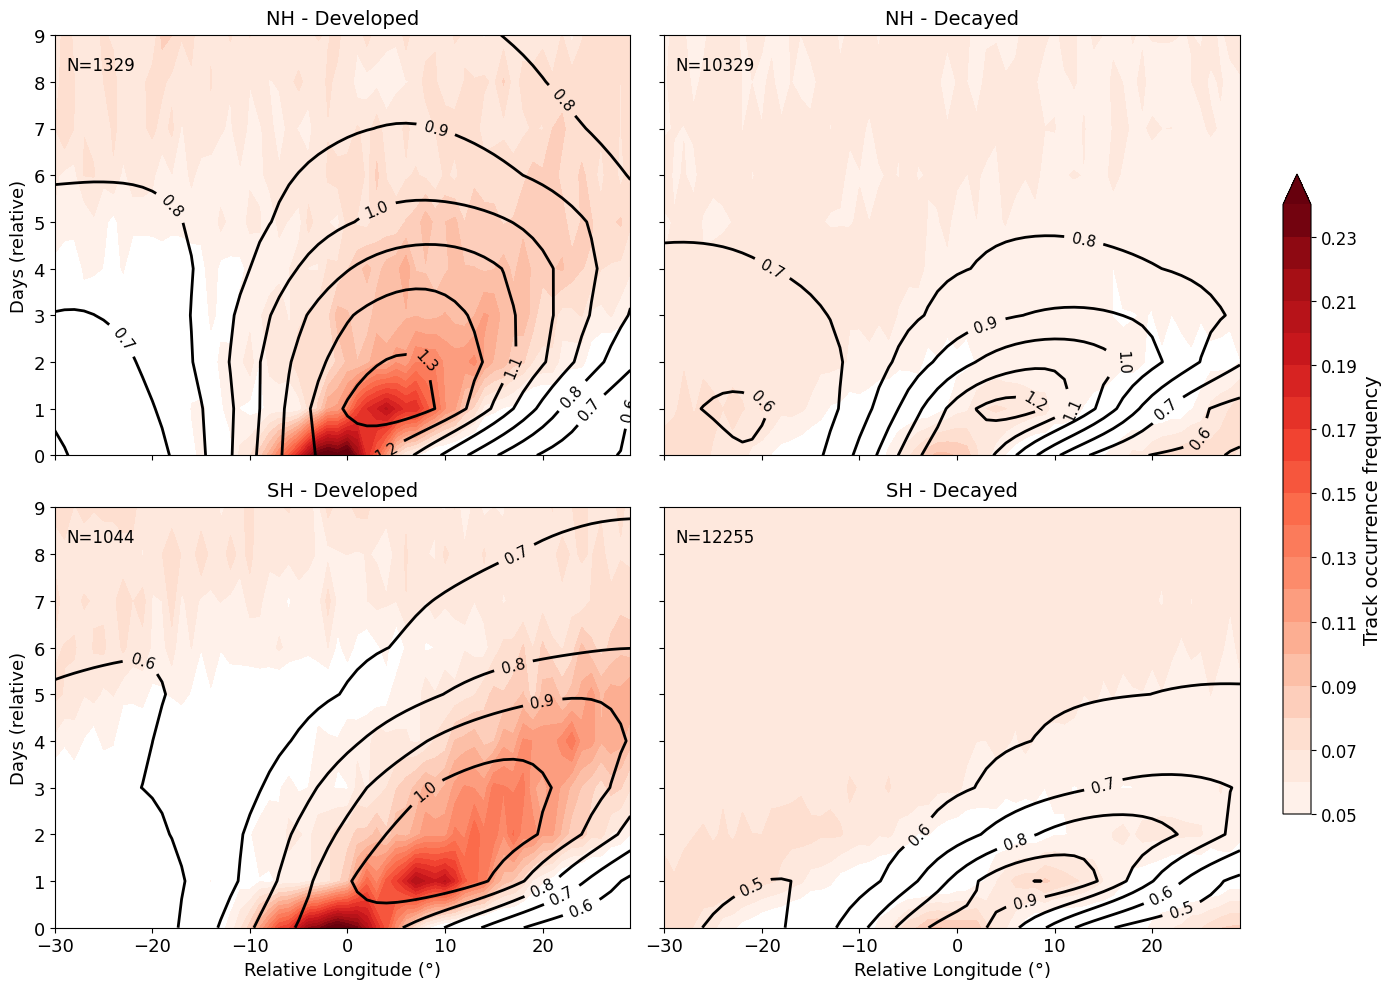

In [7]:

# ----- plot -----
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

panel_order = [
    ('NH', 'Developed'),
    ('NH', 'Decayed'),
    ('SH', 'Developed'),
    ('SH', 'Decayed')
]

for ax, (kk, situation) in zip(axes.flat, panel_order):
    cs = ax.contourf(
        lonarr, lagarr, mean_track[(kk, situation)],
        levels=levels_fill, cmap=cmap, extend='max'
    )

    cs2 = ax.contour(
        lonarr, lagarr, mean_lwa[(kk, situation)],
        colors='black', linewidths=2, levels=levels_cont
    )
    ax.clabel(cs2, inline=True, fontsize=11, fmt='%1.1f')

    ax.set_title(f'{kk} - {situation}', fontsize=14, pad=8)
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=13)

# labels
axes[1, 0].set_xlabel('Relative Longitude (°)', fontsize=13)
axes[1, 1].set_xlabel('Relative Longitude (°)', fontsize=13)
axes[0, 0].set_ylabel('Days (relative)', fontsize=13)
axes[1, 0].set_ylabel('Days (relative)', fontsize=13)

# add count annotations as N=count at upper-left corner
for ax, (kk, situation) in zip(axes.flat, panel_order):
    count = int(mean_count[(kk, situation)])
    ax.text(0.02, 0.95, f'N={count}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='left')

# colorbar
cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.64])
cbar = fig.colorbar(cs, cax=cbar_ax)
cbar.set_label('Track occurrence frequency', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

/tmp/ipykernel_795973/571979230.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


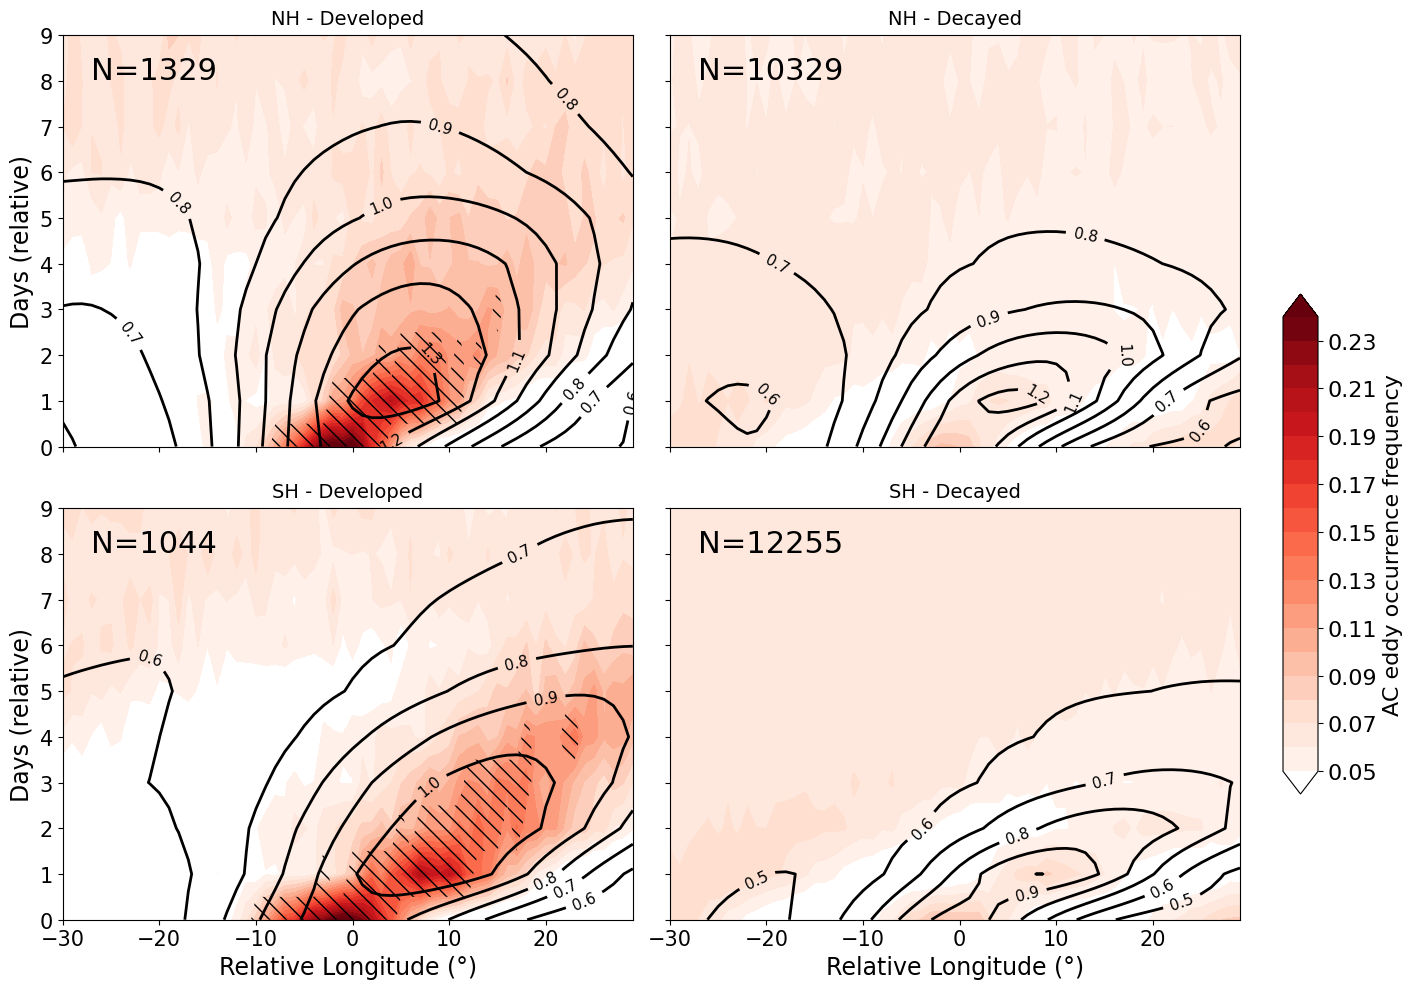

In [41]:
import numpy as np
import matplotlib.pyplot as plt

blktype = 1
trackType = 'AC'

lonarr = np.arange(-30, 30)
lagarr = np.arange(0, 10)

levels_fill = np.arange(0.05, 0.25, 0.01)
levels_cont = np.arange(0, 1.8, 0.1)

cmap = plt.get_cmap('Reds').copy()
cmap.set_under('white')

datasets = ["ERA5", "MERRA2", "JRA3Q"]
hemis = ['NH', 'SH']
situations = ['Developed', 'Decayed']

mean_lwa = {}
mean_track = {}

# for hatch agreement test
track_by_dataset = {}

for kk in hemis:
    for situation in situations:
        lwa_list = []
        track_list = []

        for dtname in datasets:
            OUTDIR = OUT_DIR_List[dtname]

            centeredComp_latavg = np.load(
                f'{OUTDIR}/{dtname}_{kk}_{blktype}_centeredComp_latavg_{situation}.npy'
            )

            centeredCompTrack_latavg = np.load(
                f'{OUTDIR}/{dtname}_{kk}_{blktype}_{trackType}_centeredCompTrack_latavg_{situation}.npy'
            )

            lwa_list.append(centeredComp_latavg)
            track_list.append(centeredCompTrack_latavg)
            track_by_dataset[(dtname, kk, situation)] = centeredCompTrack_latavg

        mean_lwa[(kk, situation)] = np.mean(np.stack(lwa_list, axis=0), axis=0)
        mean_track[(kk, situation)] = np.mean(np.stack(track_list, axis=0), axis=0)

# ----- build agreement masks -----
# mask_agree[(kk)] = True where all 3 datasets satisfy Developed >= 2 * Decayed
mask_agree = {}

for kk in hemis:
    agree_list = []
    for dtname in datasets:
        dev = track_by_dataset[(dtname, kk, 'Developed')]
        dec = track_by_dataset[(dtname, kk, 'Decayed')]

        agree_this_dataset = (dec > 0) & (dev >= 2.0 * dec)
        agree_list.append(agree_this_dataset)

    mask_agree[kk] = np.logical_and.reduce(agree_list)

# ----- plot -----
labels = ['(a)', '(b)', '(c)', '(d)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

panel_order = [
    ('NH', 'Developed'),
    ('NH', 'Decayed'),
    ('SH', 'Developed'),
    ('SH', 'Decayed')
]

for ax, (kk, situation) in zip(axes.flat, panel_order):
    cs = ax.contourf(
        lonarr, lagarr, mean_track[(kk, situation)],
        levels=levels_fill, cmap=cmap, extend='both'
    )

    cs2 = ax.contour(
        lonarr, lagarr, mean_lwa[(kk, situation)],
        colors='black', linewidths=2, levels=levels_cont
    )
    ax.clabel(cs2, inline=True, fontsize=11, fmt='%1.1f')

    # add hatches only on Developed panels
    if situation == 'Developed':
        hatch_mask = mask_agree[kk].astype(int)

        ax.contourf(
            lonarr, lagarr, hatch_mask,
            levels=[0.5, 1.5],
            colors='none',
            hatches=['\\\\'],
        ) # hatches color gray

    ax.set_title(f'{kk} - {situation}', fontsize=14, pad=8)
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=15)

# labels
axes[1, 0].set_xlabel('Relative Longitude (°)', fontsize=17)
axes[1, 1].set_xlabel('Relative Longitude (°)', fontsize=17)
axes[0, 0].set_ylabel('Days (relative)', fontsize=17)
axes[1, 0].set_ylabel('Days (relative)', fontsize=17)

# add count annotations as N=count at upper-left corner
for ax, (kk, situation) in zip(axes.flat, panel_order):
    count = int(mean_count[(kk, situation)])
    ax.text(0.05, 0.95, f'N={count}',
        transform=ax.transAxes,
        fontsize=22, color='black',
        verticalalignment='top',
        horizontalalignment='left')

# for i, (ax, (kk, situation)) in enumerate(zip(axes.flat, panel_order)):
#     # panel label
#     ax.text(0.03, 0.98, labels[i],
#             transform=ax.transAxes,
#             fontsize=18, va='top')

#     # N label
#     count = int(mean_count[(kk, situation)])
#     ax.text(0.03, 0.88, f'N={count}',
#             transform=ax.transAxes,
#             fontsize=18, va='top')

# colorbar
cbar_ax = fig.add_axes([0.92, 0.20, 0.025, 0.5]) # x=0.92, y=0.18, width=0.02, height=0.64
cbar = fig.colorbar(cs, cax=cbar_ax)
cbar.set_label('AC eddy occurrence frequency', fontsize=16)
cbar.ax.tick_params(labelsize=16)

plt.tight_layout(rect=[0, 0, 0.9, 1])
fig.subplots_adjust(hspace=0.15)

plt.savefig('./FINAL_figures/Nature_Fig2.png', dpi=300, bbox_inches='tight')
plt.show()